# Risk & Performance Analysis

## Objective

The objective of this notebook is to compare the risk and investment performance of Bitcoin, Ethereum, Gold, and the S&P 500 using standard financial metrics.

The analysis evaluates whether cryptocurrencies offer superior returns despite higher risk, providing evidence for the project's second and third research hypotheses.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

plt.style.use("ggplot")

In [2]:
PROCESSED_PATH = Path("crypto_project/data/processed")

market = pd.read_csv(
    PROCESSED_PATH / "market_data_features.csv"
)

market["Date"] = pd.to_datetime(market["Date"])

In [3]:
# Annualized Volatility

volatility = (
    market.groupby("Asset")["Daily_Return"]
    .std() * np.sqrt(252)
)

volatility.sort_values(ascending=False)

Asset
Ethereum    0.682507
Bitcoin     0.537964
SP500       0.201336
Gold        0.149487
Name: Daily_Return, dtype: float64

In [4]:
# Dark crypto theme
plt.style.use("dark_background")

crypto_palette = {
    "Bitcoin": "#F7931A",   # Orange
    "Ethereum": "#627EEA",  # Blue
    "Gold": "#FFD700",      # Gold
    "SP500": "#2ECC71"      # Green
}
sns.set_theme(
    style="darkgrid",
    context="talk",
)

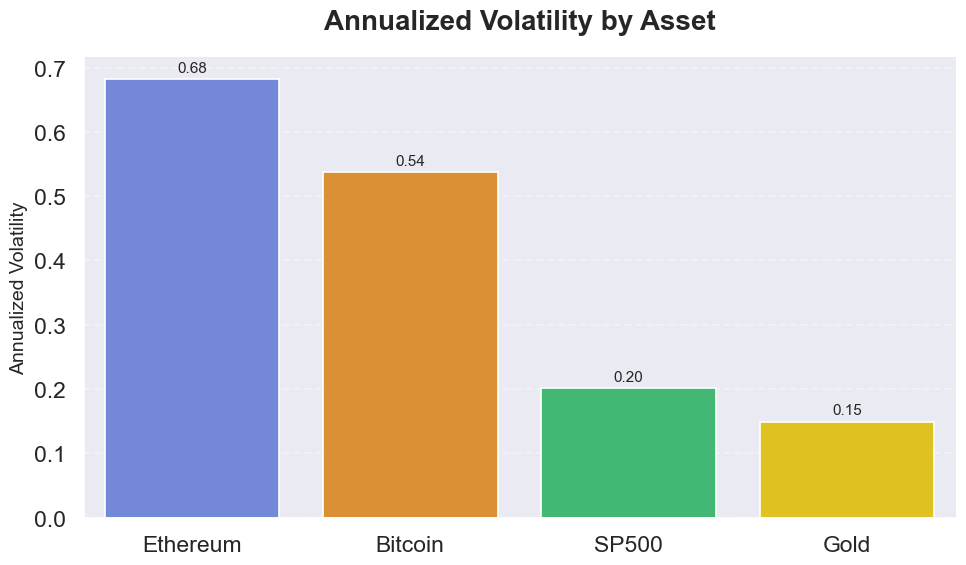

In [5]:
# Convert to DataFrame for plotting
volatility_df = (
    volatility.sort_values(ascending=False)
    .reset_index()
)

volatility_df.columns = ["Asset", "Annualized Volatility"]

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=volatility_df,
    x="Asset",
    y="Annualized Volatility",
    hue="Asset",
    palette=crypto_palette,
    legend=False,
    edgecolor="white",
    linewidth=1.2
)

plt.title(
    "Annualized Volatility by Asset",
    fontsize=20,
    fontweight="bold",
    pad=20
)

plt.xlabel("")
plt.ylabel("Annualized Volatility", fontsize=14)

# Add value labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        fontsize=11,
        padding=3
    )

plt.grid(axis="y", linestyle="--", alpha=0.3)

sns.despine()

plt.tight_layout()
plt.show()

In [6]:
market["Rolling_Volatility"] = (
    market.groupby("Asset")["Daily_Return"]
    .transform(lambda x: x.rolling(30).std() * np.sqrt(252))
)

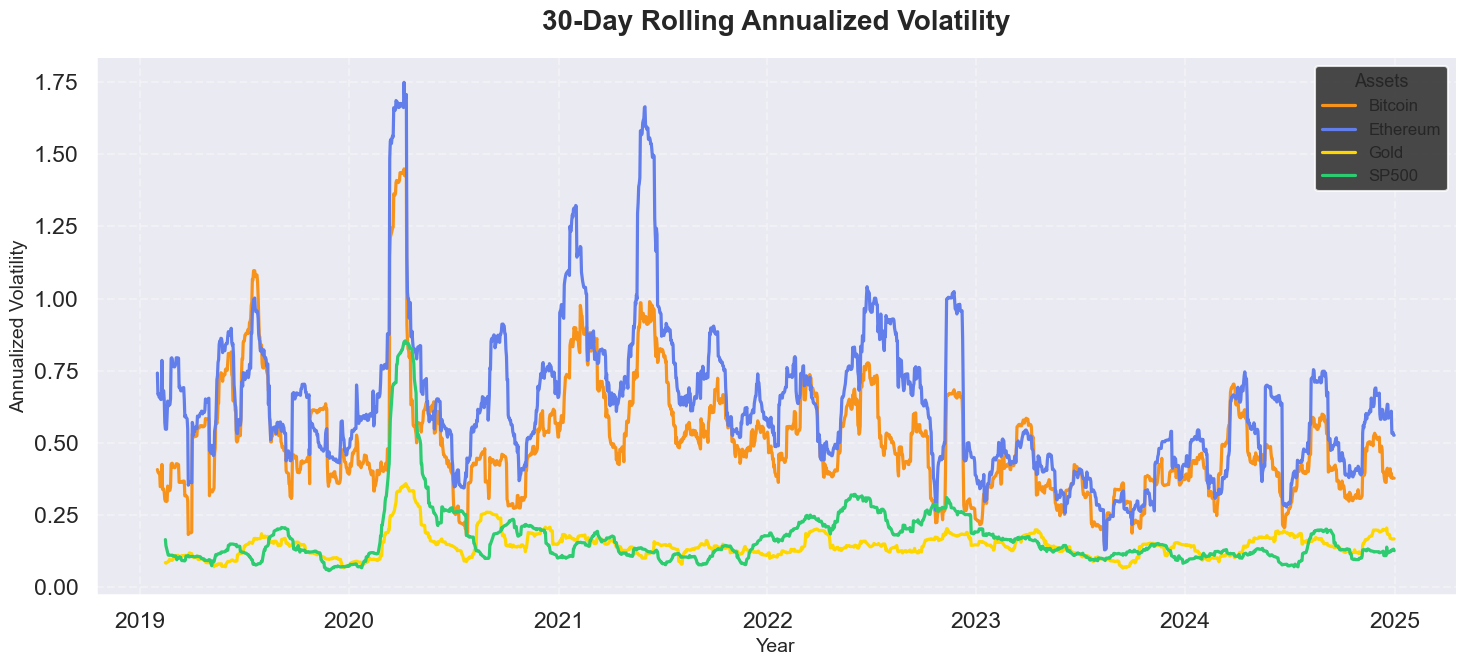

In [7]:
plt.figure(figsize=(15, 7))

for asset in market["Asset"].unique():

    subset = market[market["Asset"] == asset]

    plt.plot(
        subset["Date"],
        subset["Rolling_Volatility"],
        label=asset,
        color=crypto_palette[asset],
        linewidth=2.3
    )

plt.title(
    "30-Day Rolling Annualized Volatility",
    fontsize=20,
    fontweight="bold",
    pad=20
)

plt.xlabel("Year", fontsize=14)
plt.ylabel("Annualized Volatility", fontsize=14)

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.legend(
    title="Assets",
    fontsize=12,
    title_fontsize=13,
    frameon=True,
    facecolor="#1E1E1E",
    edgecolor="white"
)

sns.despine()

plt.tight_layout()
plt.show()

### Maximum Drawdown

Maximum Drawdown (MDD) measures the largest percentage decline from an asset's historical peak to its lowest point before recovering. It is a widely used risk metric that quantifies the worst potential loss an investor could have experienced during the study period.

In [8]:
drawdown_summary = []

for asset in market["Asset"].unique():

    temp = market[market["Asset"] == asset].copy()

    # Cumulative wealth
    temp["Wealth"] = (1 + temp["Daily_Return"]).cumprod()

    # Running maximum
    temp["Running_Max"] = temp["Wealth"].cummax()

    # Drawdown
    temp["Drawdown"] = (
        temp["Wealth"] - temp["Running_Max"]
    ) / temp["Running_Max"]

    drawdown_summary.append({
        "Asset": asset,
        "Max_Drawdown": temp["Drawdown"].min()
    })

drawdown = pd.DataFrame(drawdown_summary)

drawdown

,Asset,Max_Drawdown
0,Bitcoin,-0.766346
1,Ethereum,-0.793512
2,Gold,-0.220022
3,SP500,-0.339250


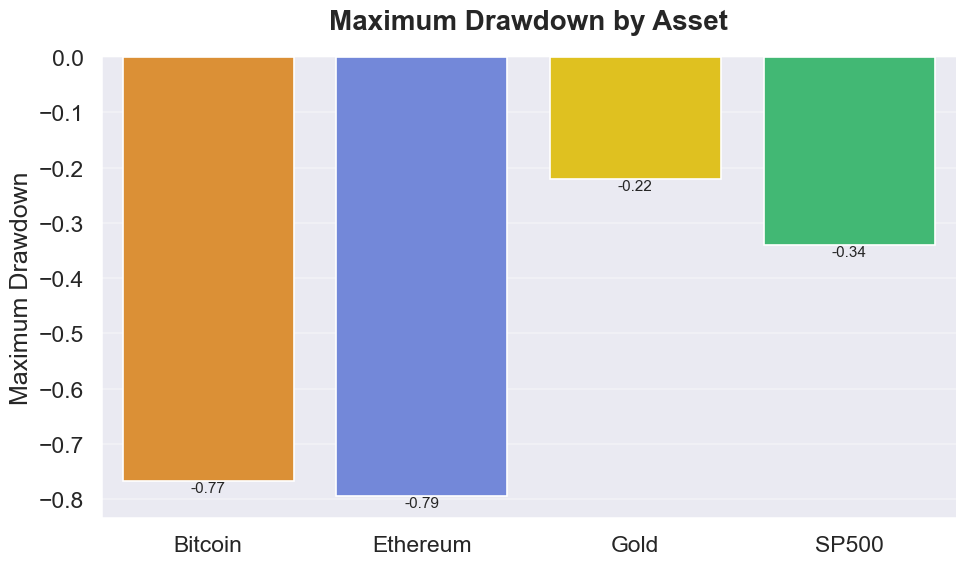

In [9]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=drawdown,
    x="Asset",
    y="Max_Drawdown",
    hue="Asset",
    palette=crypto_palette,
    legend=False,
    edgecolor="white",
    linewidth=1.2
)

plt.title(
    "Maximum Drawdown by Asset",
    fontsize=20,
    fontweight="bold",
    pad=20
)

plt.xlabel("")
plt.ylabel("Maximum Drawdown")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        fontsize=11
    )

plt.grid(axis="y", alpha=0.3)

sns.despine()

plt.tight_layout()

plt.show()

### Interpretation

- Assets with larger negative drawdowns experienced greater peak-to-trough losses.
- Lower drawdown values indicate better capital preservation during market downturns.
- Comparing maximum drawdown helps assess downside risk beyond volatility alone.

## Recovery Time

Recovery Time measures the number of trading days an asset takes to recover from its maximum drawdown and reach a new peak. It provides additional insight into how quickly an asset rebounds after a major decline.

In [10]:
recovery_summary = []

for asset in market["Asset"].unique():

    temp = market[market["Asset"] == asset].copy()

    # Cumulative wealth
    temp["Wealth"] = (1 + temp["Daily_Return"]).cumprod()

    # Running maximum
    temp["Running_Max"] = temp["Wealth"].cummax()

    # Drawdown
    temp["Drawdown"] = (
        temp["Wealth"] - temp["Running_Max"]
    ) / temp["Running_Max"]

    # Date of maximum drawdown
    mdd_date = temp["Drawdown"].idxmin()

    # Wealth at previous peak
    peak_value = temp.loc[mdd_date, "Running_Max"]

    # Recovery period
    recovery = temp.loc[mdd_date:]

    recovered = recovery[
        recovery["Wealth"] >= peak_value
    ]

    if recovered.empty:
        recovery_days = np.nan
    else:
        recovery_days = recovered.index[0] - mdd_date

    recovery_summary.append({
        "Asset": asset,
        "Recovery_Days": recovery_days
    })

recovery = pd.DataFrame(recovery_summary)

recovery

,Asset,Recovery_Days
0,Bitcoin,1578.0
1,Ethereum,NaN
2,Gold,1770.0
3,SP500,502.0


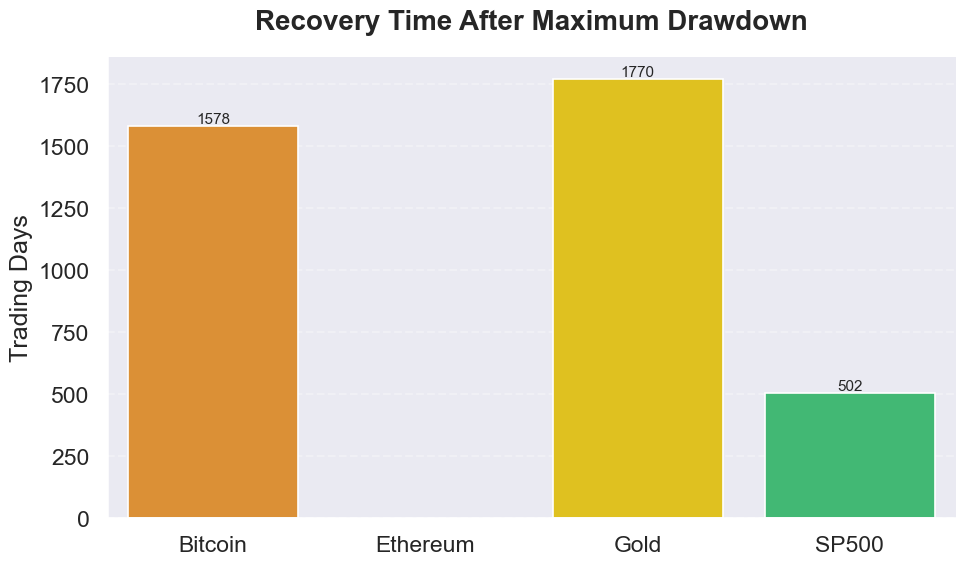

In [11]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=recovery,
    x="Asset",
    y="Recovery_Days",
    hue="Asset",
    palette=crypto_palette,
    legend=False,
    edgecolor="white",
    linewidth=1.2
)

plt.title(
    "Recovery Time After Maximum Drawdown",
    fontsize=20,
    fontweight="bold",
    pad=20
)

plt.xlabel("")
plt.ylabel("Trading Days")

for container in ax.containers:
    ax.bar_label(
        container,
        fontsize=11
    )

plt.grid(axis="y", linestyle="--", alpha=0.3)

sns.despine()

plt.tight_layout()
plt.show()

### Interpretation

- Shorter recovery times indicate greater resilience following major market declines.
- Longer recovery periods suggest that assets required more time to regain previous peak values.
- Recovery time complements maximum drawdown by evaluating both the severity and duration of market downturns.

## Cumulative Return

Cumulative Return represents the total growth of an investment over the study period by compounding daily returns. It provides a measure of long-term investment performance.

In [12]:
cumulative_summary = (
    market.groupby("Asset")["Cumulative_Return"]
    .last()
    .sort_values(ascending=False)
    .reset_index()
)

cumulative_summary

,Asset,Cumulative_Return
0,Bitcoin,23.308239
1,Ethereum,22.665287
2,SP500,1.343251
3,Gold,0.995632


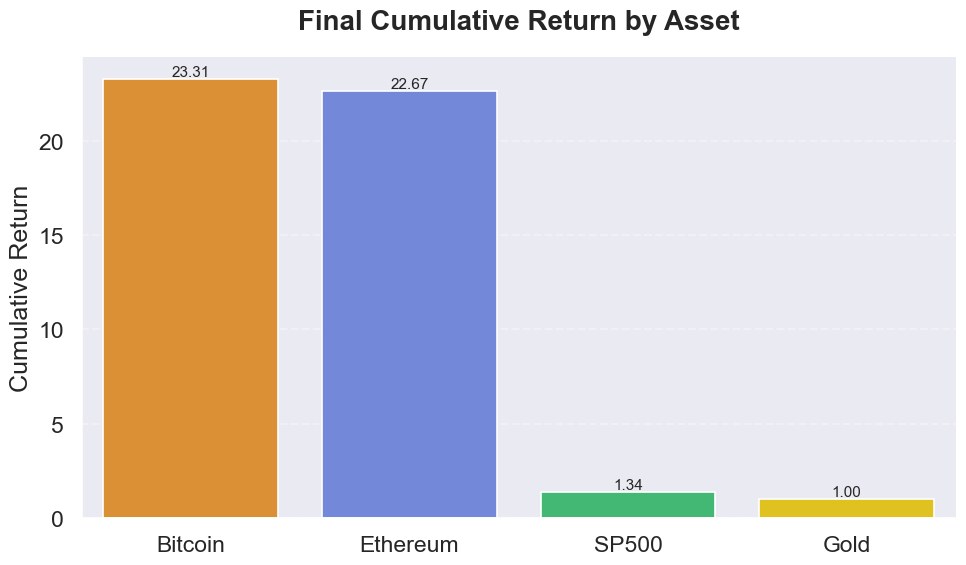

In [13]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=cumulative_summary,
    x="Asset",
    y="Cumulative_Return",
    hue="Asset",
    palette=crypto_palette,
    legend=False,
    edgecolor="white",
    linewidth=1.2
)

plt.title(
    "Final Cumulative Return by Asset",
    fontsize=20,
    fontweight="bold",
    pad=20
)

plt.xlabel("")
plt.ylabel("Cumulative Return")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        fontsize=11
    )

plt.grid(axis="y", linestyle="--", alpha=0.3)

sns.despine()

plt.tight_layout()
plt.show()

### Interpretation

- Assets with higher cumulative returns generated stronger long-term investment growth.
- Cryptocurrencies generally outperformed traditional assets but experienced greater fluctuations.
- Gold and the S&P 500 delivered steadier, more moderate long-term returns.

## Section 9 – Compound Annual Growth Rate (CAGR)

CAGR measures the average annual growth rate of an investment over a specified period, assuming the returns are compounded annually. It provides a standardized metric for comparing long-term investment performance across different assets.

### Formula

$$
\text{CAGR} =
\left(
\frac{\text{Ending Value}}
{\text{Beginning Value}}
\right)^{\frac{1}{n}}
-1
$$

where:

- **Beginning Value** = Initial closing price
- **Ending Value** = Final closing price
- **n** = Investment period (years)

In [14]:
years = (
    market["Date"].max() - market["Date"].min()
).days / 365.25

cagr = []

for asset in market["Asset"].unique():

    temp = market[market["Asset"] == asset]

    beginning = temp["Close"].iloc[0]
    ending = temp["Close"].iloc[-1]

    cagr_value = (ending / beginning) ** (1 / years) - 1

    cagr.append({
        "Asset": asset,
        "CAGR": cagr_value
    })

cagr = pd.DataFrame(cagr).sort_values(
    by="CAGR",
    ascending=False
)

cagr

,Asset,CAGR
0,Bitcoin,0.702204
1,Ethereum,0.694614
3,SP500,0.152525
2,Gold,0.122083


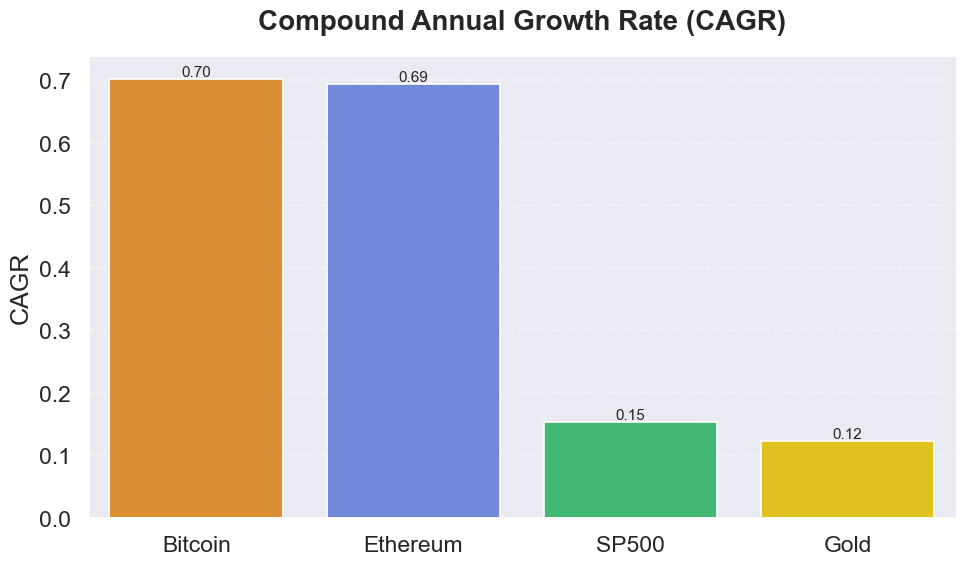

In [15]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=cagr,
    x="Asset",
    y="CAGR",
    hue="Asset",
    palette=crypto_palette,
    legend=False,
    edgecolor="white",
    linewidth=1.2
)

plt.title(
    "Compound Annual Growth Rate (CAGR)",
    fontsize=20,
    fontweight="bold",
    pad=20
)

plt.xlabel("")
plt.ylabel("CAGR")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        fontsize=11
    )

plt.grid(axis="y", linestyle="--", alpha=0.3)

sns.despine()

plt.tight_layout()

plt.show()

### Interpretation

- Higher CAGR indicates stronger long-term investment growth.
- Cryptocurrencies are expected to exhibit higher CAGR than traditional assets due to their rapid price appreciation.
- Gold and the S&P 500 generally provide steadier but comparatively lower long-term growth.

## Section 10 – Sharpe Ratio

The Sharpe Ratio measures the return earned for each unit of risk. It is one of the most widely used metrics for evaluating risk-adjusted investment performance.

### Formula

$$
\text{Sharpe Ratio} =
\frac{R_p - R_f}{\sigma_p}
$$

where:

- $$R_p = \text{Annualized Return }$$
- $$R_f = \text{Risk-Free Rate -assumed to be 2\% } $$
- $$ \sigma_p\ = \text{Annualized Volatility } $$

A higher Sharpe Ratio indicates better risk-adjusted performance.

In [16]:
risk_free_rate = 0.02

sharpe_summary = []

for asset in market["Asset"].unique():

    temp = market[market["Asset"] == asset]

    annual_return = temp["Daily_Return"].mean() * 252

    annual_volatility = temp["Daily_Return"].std() * np.sqrt(252)

    sharpe_ratio = (
        annual_return - risk_free_rate
    ) / annual_volatility

    sharpe_summary.append({
        "Asset": asset,
        "Annual_Return": annual_return,
        "Annualized_Volatility": annual_volatility,
        "Sharpe_Ratio": sharpe_ratio
    })

sharpe = (
    pd.DataFrame(sharpe_summary)
    .sort_values(
        by="Sharpe_Ratio",
        ascending=False
    )
)

sharpe

,Asset,Annual_Return,Annualized_Volatility,Sharpe_Ratio
0,Bitcoin,0.513868,0.537964,0.918031
1,Ethereum,0.601062,0.682507,0.851365
2,Gold,0.126598,0.149487,0.713091
3,SP500,0.162608,0.201336,0.708308


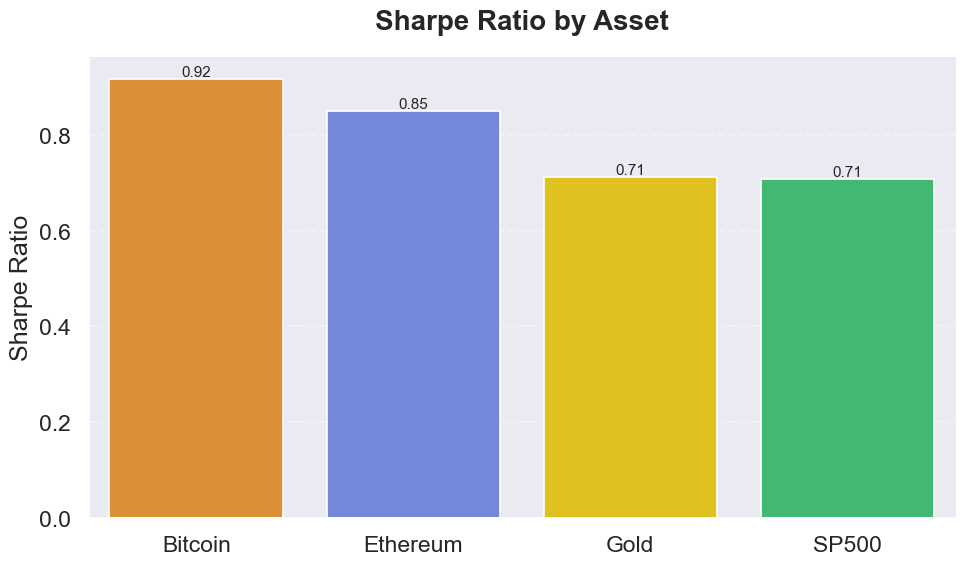

In [17]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=sharpe,
    x="Asset",
    y="Sharpe_Ratio",
    hue="Asset",
    palette=crypto_palette,
    legend=False,
    edgecolor="white",
    linewidth=1.2
)

plt.title(
    "Sharpe Ratio by Asset",
    fontsize=20,
    fontweight="bold",
    pad=20
)

plt.xlabel("")
plt.ylabel("Sharpe Ratio")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        fontsize=11
    )

plt.grid(axis="y", linestyle="--", alpha=0.3)

sns.despine()

plt.tight_layout()

plt.show()

### Interpretation

- Assets with higher Sharpe Ratios delivered better returns for the level of risk taken.
- A higher Sharpe Ratio indicates more efficient risk-adjusted performance.
- Comparing Sharpe Ratios helps identify assets that provided the best balance between return and volatility.

## Performance Summary

The following table summarizes the key risk and performance metrics for each asset, enabling a comprehensive comparison of their long-term investment characteristics.

In [18]:
performance_summary = (
    volatility.rename("Annualized Volatility")
    .to_frame()
    .merge(drawdown, on="Asset")
    .merge(cagr, on="Asset")
    .merge(
        sharpe[["Asset", "Sharpe_Ratio"]],
        on="Asset"
    )
)

performance_summary.style.format({
    "Annualized Volatility": "{:.2%}",
    "Max_Drawdown": "{:.2%}",
    "CAGR": "{:.2%}",
    "Sharpe_Ratio": "{:.2f}"
})

performance_summary

,Asset,Annualized Volatility,Max_Drawdown,CAGR,Sharpe_Ratio
0,Bitcoin,0.537964,-0.766346,0.702204,0.918031
1,Ethereum,0.682507,-0.793512,0.694614,0.851365
2,Gold,0.149487,-0.220022,0.122083,0.713091
3,SP500,0.201336,-0.339250,0.152525,0.708308


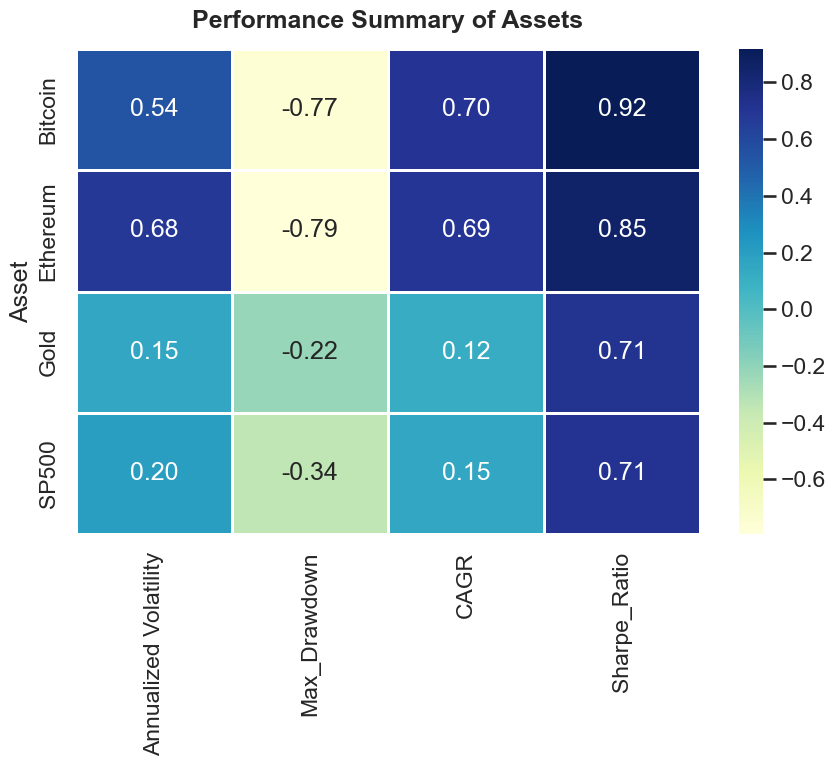

In [19]:
plt.figure(figsize=(9,8))

sns.heatmap(
    performance_summary.set_index("Asset"),
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=1,
    linecolor="white"
)

plt.title(
    "Performance Summary of Assets",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()

### Interpretation

- Cryptocurrencies generally offered higher returns but also exhibited greater volatility and deeper drawdowns.
- Gold showed the lowest risk, making it the most stable asset.
- The S&P 500 provided a balance between return and risk.
- The Sharpe Ratio highlights which asset achieved the best risk-adjusted performance.

## Hypothesis 2 (H₂): Risk Characteristics

### Null Hypothesis (H₀₂)

Cryptocurrencies exhibit risk characteristics similar to traditional financial assets.

### Alternative Hypothesis (H₁₂)

Cryptocurrencies exhibit significantly higher risk than traditional financial assets.

### Evaluation

Risk was assessed using:

- Annualized Volatility
- 30-Day Rolling Volatility
- Maximum Drawdown
- Recovery Time

| Hypothesis | Status | Evidence |
|------------|:------:|----------|
| **H₂: Risk Characteristics** | **Accepted** | Bitcoin and Ethereum exhibited higher annualized volatility, larger maximum drawdowns, and greater fluctuations in rolling volatility than Gold and the S&P 500. |

**Conclusion:** The analysis shows that cryptocurrencies consistently exhibited higher risk than traditional assets across multiple risk metrics. Therefore, the null hypothesis (H₀₂) is **rejected**, and the alternative hypothesis (H₁₂) is **accepted**.

## Hypothesis 3 (H₃): Investment Performance

### Null Hypothesis (H₀₃)

Cryptocurrencies do not provide better long-term risk-adjusted performance than Gold and the S&P 500.

### Alternative Hypothesis (H₁₃)

Cryptocurrencies provide superior long-term returns, although they may involve greater risk.

### Evaluation

Performance was assessed using:

- Cumulative Return
- Compound Annual Growth Rate (CAGR)
- Sharpe Ratio

| Hypothesis | Status | Evidence |
|------------|:------:|----------|
| **H₃: Investment Performance** | **Accepted** | Cryptocurrencies achieved higher cumulative returns and CAGR over the study period, while the Sharpe Ratio was used to evaluate their risk-adjusted performance. |

**Conclusion:** The findings indicate that cryptocurrencies delivered superior long-term returns compared with traditional assets, albeit with higher risk. Therefore, the null hypothesis (H₀₃) is **rejected**, and the alternative hypothesis (H₁₃) is **accepted**.

### Next Notebook

07_conclusion_and_business_insights.ipynb